In [2]:
# In meaningfully, we wrote down the words that came up from the messages obtained using "Sensationalised or overly graphic descriptions of violence that objectify survivors and victims or in opposition to this, minimising the severity of the crime through euphemistic terminology."
# (from https://www.womankind.org.uk/the-language-of-gender-based-violence-reporting/)
# we did this because we couldn't get a list of words that could be responsible for re traumatisation of victims online

In [3]:
import pandas as pd
df = pd.read_csv("messages_clean_ALL.csv")
df.head(5)



,Channel Name,Date,Time,Link,Message,cleaned_Message,tokenized_Message,lemmatized_Message
0,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da...",l homme de type maghrebin l aurait suivie dans...,"['l', 'homme', 'de', 'type', 'maghrebin', 'l',...","['homme', 'type', 'maghrebin', 'suivie', 'rue'..."
1,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...,on continue le tour de nos belles sections ave...,"['on', 'continue', 'le', 'tour', 'de', 'nos', ...","['continue', 'tour', 'no', 'belle', 'section',..."
2,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...,le cio retabli les tests genetiques de feminit...,"['le', 'cio', 'retabli', 'les', 'tests', 'gene...","['cio', 'retabli', 'test', 'genetiques', 'femi..."
3,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️,notre section bordeaux,"['notre', 'section', 'bordeaux']","['section', 'bordeaux']"
4,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem...",trois hommes intervenus pour defendre des femm...,"['trois', 'hommes', 'intervenus', 'pour', 'def...","['trois', 'hommes', 'intervenus', 'defendre', ..."


In [4]:
df.shape


(2024, 8)

In [16]:
import nltk
from nltk.corpus import wordnet as wn
from collections import Counter
import ast
from collections import Counter
import re

In [17]:
#join all the lemmatised bits of words into one
all_words = " ".join([" ".join(words) for words in df["lemmatized_Message"]])
all_words


"[ ' h o m m e ' ,   ' t y p e ' ,   ' m a g h r e b i n ' ,   ' s u i v i e ' ,   ' r u e ' ,   ' a v a n t ' ,   ' c o i n c e r ' ,   ' j e u n e ' ,   ' v i c t i m e ' ,   ' m a i n t e n a n t ' ,   ' b r a ' ,   ' m a i n ' ,   ' m o r d a n t ' ,   ' a r r a c h a n t ' ,   ' b o u t o n s ' ,   ' j e a n ' ,   ' e n s u i t e ' ,   ' t e n t e ' ,   ' p e n e t r e r ' ,   ' s a n s ' ,   ' p a r v e n i r ' ,   ' t o t a l e m e n t ' ,   ' b l e s s a n t ' ,   ' p a s s a g e ' ,   ' j e u n e ' ,   ' f i l l e ' ,   ' p a r t y ' ,   ' i n t i m e s ' ,   ' c e l l e c i ' ,   ' d e b a t t u e ' ,   ' a ' ,   ' h u r l e ' ,   ' c o u r a g e ' ,   ' a ' ,   ' h e u r e ' ,   ' e c r i v o n s ' ,   ' l i g n e ' ,   ' m a m a n ' ,   ' t e m o i g n e ' ,   ' s a i g n e ' ,   ' e n c o r e ' ,   ' c o l l e c t i f ' ,   ' n e m e s i s ' ,   ' j o i n t ' ,   ' a ' ,   ' d o u l e u r ' ,   ' c e t t e ' ,   ' j e u n e ' ,   ' f i l l e ' ,   ' f a m i l l e ' ,   ' a

In [18]:
#clean it 

spaced_words = re.findall(r"'(.*?)'", all_words)
spaced_words

[' h o m m e ',
 ' t y p e ',
 ' m a g h r e b i n ',
 ' s u i v i e ',
 ' r u e ',
 ' a v a n t ',
 ' c o i n c e r ',
 ' j e u n e ',
 ' v i c t i m e ',
 ' m a i n t e n a n t ',
 ' b r a ',
 ' m a i n ',
 ' m o r d a n t ',
 ' a r r a c h a n t ',
 ' b o u t o n s ',
 ' j e a n ',
 ' e n s u i t e ',
 ' t e n t e ',
 ' p e n e t r e r ',
 ' s a n s ',
 ' p a r v e n i r ',
 ' t o t a l e m e n t ',
 ' b l e s s a n t ',
 ' p a s s a g e ',
 ' j e u n e ',
 ' f i l l e ',
 ' p a r t y ',
 ' i n t i m e s ',
 ' c e l l e c i ',
 ' d e b a t t u e ',
 ' a ',
 ' h u r l e ',
 ' c o u r a g e ',
 ' a ',
 ' h e u r e ',
 ' e c r i v o n s ',
 ' l i g n e ',
 ' m a m a n ',
 ' t e m o i g n e ',
 ' s a i g n e ',
 ' e n c o r e ',
 ' c o l l e c t i f ',
 ' n e m e s i s ',
 ' j o i n t ',
 ' a ',
 ' d o u l e u r ',
 ' c e t t e ',
 ' j e u n e ',
 ' f i l l e ',
 ' f a m i l l e ',
 ' a i n s i ',
 ' a ',
 ' c o l e r e ',
 ' r e m e r c i o n s ',
 ' c o n f i a n c e ',
 ' t e m o i g

In [19]:
#take off the white spaces between characters

cleaned_words = [word.replace(" ", "") for word in spaced_words]
cleaned_words

['homme',
 'type',
 'maghrebin',
 'suivie',
 'rue',
 'avant',
 'coincer',
 'jeune',
 'victime',
 'maintenant',
 'bra',
 'main',
 'mordant',
 'arrachant',
 'boutons',
 'jean',
 'ensuite',
 'tente',
 'penetrer',
 'sans',
 'parvenir',
 'totalement',
 'blessant',
 'passage',
 'jeune',
 'fille',
 'party',
 'intimes',
 'celleci',
 'debattue',
 'a',
 'hurle',
 'courage',
 'a',
 'heure',
 'ecrivons',
 'ligne',
 'maman',
 'temoigne',
 'saigne',
 'encore',
 'collectif',
 'nemesis',
 'joint',
 'a',
 'douleur',
 'cette',
 'jeune',
 'fille',
 'famille',
 'ainsi',
 'a',
 'colere',
 'remercions',
 'confiance',
 'temoignent',
 'jurons',
 'combat',
 'cessera',
 'jamais',
 'tant',
 'victimes',
 'pleureront',
 'esperons',
 'monstre',
 'a',
 'attaquee',
 'serum',
 'severement',
 'puni',
 'justice',
 'fera',
 'travail',
 'no',
 'mere',
 'no',
 'no',
 'fille',
 'continue',
 'tour',
 'no',
 'belle',
 'section',
 'dijon',
 'belfort',
 'besancon',
 'cio',
 'retabli',
 'test',
 'genetiques',
 'feminite',
 'part

In [20]:
#using a list comprehension
filtered_words = [re.sub(r"\bhttp\S*", " ", word) for word in cleaned_words]
filtered_words

['homme',
 'type',
 'maghrebin',
 'suivie',
 'rue',
 'avant',
 'coincer',
 'jeune',
 'victime',
 'maintenant',
 'bra',
 'main',
 'mordant',
 'arrachant',
 'boutons',
 'jean',
 'ensuite',
 'tente',
 'penetrer',
 'sans',
 'parvenir',
 'totalement',
 'blessant',
 'passage',
 'jeune',
 'fille',
 'party',
 'intimes',
 'celleci',
 'debattue',
 'a',
 'hurle',
 'courage',
 'a',
 'heure',
 'ecrivons',
 'ligne',
 'maman',
 'temoigne',
 'saigne',
 'encore',
 'collectif',
 'nemesis',
 'joint',
 'a',
 'douleur',
 'cette',
 'jeune',
 'fille',
 'famille',
 'ainsi',
 'a',
 'colere',
 'remercions',
 'confiance',
 'temoignent',
 'jurons',
 'combat',
 'cessera',
 'jamais',
 'tant',
 'victimes',
 'pleureront',
 'esperons',
 'monstre',
 'a',
 'attaquee',
 'serum',
 'severement',
 'puni',
 'justice',
 'fera',
 'travail',
 'no',
 'mere',
 'no',
 'no',
 'fille',
 'continue',
 'tour',
 'no',
 'belle',
 'section',
 'dijon',
 'belfort',
 'besancon',
 'cio',
 'retabli',
 'test',
 'genetiques',
 'feminite',
 'part

In [21]:
final_words = [word for word in cleaned_words 
               if "http" not in word and "www" not in word ]
final_words

['homme',
 'type',
 'maghrebin',
 'suivie',
 'rue',
 'avant',
 'coincer',
 'jeune',
 'victime',
 'maintenant',
 'bra',
 'main',
 'mordant',
 'arrachant',
 'boutons',
 'jean',
 'ensuite',
 'tente',
 'penetrer',
 'sans',
 'parvenir',
 'totalement',
 'blessant',
 'passage',
 'jeune',
 'fille',
 'party',
 'intimes',
 'celleci',
 'debattue',
 'a',
 'hurle',
 'courage',
 'a',
 'heure',
 'ecrivons',
 'ligne',
 'maman',
 'temoigne',
 'saigne',
 'encore',
 'collectif',
 'nemesis',
 'joint',
 'a',
 'douleur',
 'cette',
 'jeune',
 'fille',
 'famille',
 'ainsi',
 'a',
 'colere',
 'remercions',
 'confiance',
 'temoignent',
 'jurons',
 'combat',
 'cessera',
 'jamais',
 'tant',
 'victimes',
 'pleureront',
 'esperons',
 'monstre',
 'a',
 'attaquee',
 'serum',
 'severement',
 'puni',
 'justice',
 'fera',
 'travail',
 'no',
 'mere',
 'no',
 'no',
 'fille',
 'continue',
 'tour',
 'no',
 'belle',
 'section',
 'dijon',
 'belfort',
 'besancon',
 'cio',
 'retabli',
 'test',
 'genetiques',
 'feminite',
 'part

In [22]:
#chek whether the links are gone 

target = "http"

if any(target in word for word in final_words):
    print(f"Yes, there is a word that contains '{target}'!")
else:
    print (f"No, there are no words that contain '{target}'")

No, there are no words that contain 'http'


In [23]:
target = "www"

if any(target in word for word in final_words):
    print(f"Yes, there is a word that contains '{target}'!")
else:
    print (f"No, there are no words that contain '{target}'")

No, there are no words that contain 'www'


In [24]:
#transform the data into a string, ahead of using spacy library
final_words_string = " ".join(final_words)
type(final_words_string)

str

In [25]:
#use spacy to remove any punctionation words, auxiliary verbs
import spacy 
nlp = spacy.load("fr_core_news_sm")

doc = nlp(final_words_string)

cleaned_words2 = [
    token.text for token in doc 
    if token.pos_ not in ["AUX", "DET", "ADP", "CCONJ", "SCONJ", "PUNCT"]
]


In [26]:
cleaned_words2

['homme',
 'type',
 'maghrebin',
 'suivie',
 'rue',
 'coincer',
 'jeune',
 'victime',
 'maintenant',
 'bra',
 'main',
 'mordant',
 'arrachant',
 'boutons',
 'jean',
 'ensuite',
 'tente',
 'penetrer',
 'parvenir',
 'totalement',
 'blessant',
 'passage',
 'jeune',
 'fille',
 'party',
 'intimes',
 'celleci',
 'debattue',
 'hurle',
 'courage',
 'heure',
 'ecrivons',
 'ligne',
 'maman',
 'temoigne',
 'saigne',
 'encore',
 'collectif',
 'nemesis',
 'joint',
 'douleur',
 'jeune',
 'fille',
 'famille',
 'ainsi',
 'colere',
 'remercions',
 'confiance',
 'temoignent',
 'jurons',
 'combat',
 'cessera',
 'jamais',
 'tant',
 'victimes',
 'pleureront',
 'esperons',
 'monstre',
 'attaquee',
 'serum',
 'severement',
 'puni',
 'justice',
 'fera',
 'travail',
 'no',
 'mere',
 'no',
 'no',
 'fille',
 'continue',
 'tour',
 'no',
 'belle',
 'section',
 'dijon',
 'belfort',
 'besancon',
 'cio',
 'retabli',
 'test',
 'genetiques',
 'feminite',
 'participer',
 'admissibilite',
 'competition',
 'olympiques',
 

In [27]:
#checking for the short words that have survived the previous filters, but that we are not interested in

short_words = [
    token.text for token in doc 
    if token.pos_ in ["VERB", "AUX"] and len(token.text) in [1, 2, 3]
]

print(short_words)

['a', 'a', 'a', 'a', 'a', 'a', 'ete', 'a', 'sou', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'bra', 'a', 'a', 'a', 'a', 'a', 'su', 'ete', 'a', 'a', 'mot', 'a', 'a', 'a', 'a', 'a', 'a', 'va', 'a', 'a', 'a', 'a', 'a', 'nid', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'pu', 'a', 'vux', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'ete', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'va', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'lez', 'pu', 'a', 'a', 'a', 'a', 'a', 'ete', 'a', 'ete', 'a', 'a', 'eva', 'a', 'a', 'a', 'pu', 'a', 'a', 'ete', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'ete', 'a', 'a', 'a', 'a', 'a', 'sou', 'a', 'a', 'a', 'a', 'a', 'nie', 'a', 'a', 'a', 'a', 'ete', 'a', 'ben', 'va', 'a', 'a', 'a', 'a', 'a', 'ete', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a',

In [28]:
#list of all the words but this time, unique (each word that is repeated several times is counted once instead)

short_words2 = list(set(short_words))
short_words2 

['rif',
 'cri',
 'bel',
 'ex',
 'chu',
 'epr',
 'ere',
 'age',
 'vit',
 'mot',
 'vux',
 'sic',
 'man',
 'w',
 'mi',
 'e',
 'an',
 'bfm',
 'rip',
 'ado',
 'sol',
 'vue',
 'nu',
 'ca',
 'cur',
 'eme',
 'ete',
 'cru',
 'but',
 'el',
 'ajd',
 'tvl',
 'elu',
 'pu',
 'xie',
 'agi',
 'ter',
 'tv',
 'va',
 'ald',
 'st',
 'pot',
 'pa',
 'bar',
 'lez',
 'nie',
 'met',
 'su',
 'no',
 'tnt',
 'rit',
 'fac',
 'mer',
 'itt',
 'nid',
 'dit',
 'sou',
 'mur',
 'nue',
 'ben',
 'gpa',
 'csa',
 'eva',
 'rut',
 'fui',
 'a',
 'er',
 'ob',
 'bra',
 'jl',
 'ah',
 'vu',
 'ira',
 'h',
 'job',
 'nun',
 'col',
 'tgv',
 'faq',
 'feu',
 'oui',
 'rer']

In [29]:
words_to_keep = {"cri", "bel", "ado", "feu", "elu", "rer", "mot", "vue", "sol", "nie", "bfm", "csa", "cru","mur", "mer", "rit", "ter", "eva", "ben", "fac", "nid", "bar", "rut", "tnt"}

short_words3 = set(short_words2) - words_to_keep
short_words3

{'a',
 'age',
 'agi',
 'ah',
 'ajd',
 'ald',
 'an',
 'bra',
 'but',
 'ca',
 'chu',
 'col',
 'cur',
 'dit',
 'e',
 'el',
 'eme',
 'epr',
 'er',
 'ere',
 'ete',
 'ex',
 'faq',
 'fui',
 'gpa',
 'h',
 'ira',
 'itt',
 'jl',
 'job',
 'lez',
 'man',
 'met',
 'mi',
 'no',
 'nu',
 'nue',
 'nun',
 'ob',
 'oui',
 'pa',
 'pot',
 'pu',
 'rif',
 'rip',
 'sic',
 'sou',
 'st',
 'su',
 'tgv',
 'tv',
 'tvl',
 'va',
 'vit',
 'vu',
 'vux',
 'w',
 'xie'}

In [30]:
#taking these short words out of the cleaned list 

cleaned_words3 = [word for word in cleaned_words2 if word not in short_words3]
cleaned_words3

['homme',
 'type',
 'maghrebin',
 'suivie',
 'rue',
 'coincer',
 'jeune',
 'victime',
 'maintenant',
 'main',
 'mordant',
 'arrachant',
 'boutons',
 'jean',
 'ensuite',
 'tente',
 'penetrer',
 'parvenir',
 'totalement',
 'blessant',
 'passage',
 'jeune',
 'fille',
 'party',
 'intimes',
 'celleci',
 'debattue',
 'hurle',
 'courage',
 'heure',
 'ecrivons',
 'ligne',
 'maman',
 'temoigne',
 'saigne',
 'encore',
 'collectif',
 'nemesis',
 'joint',
 'douleur',
 'jeune',
 'fille',
 'famille',
 'ainsi',
 'colere',
 'remercions',
 'confiance',
 'temoignent',
 'jurons',
 'combat',
 'cessera',
 'jamais',
 'tant',
 'victimes',
 'pleureront',
 'esperons',
 'monstre',
 'attaquee',
 'serum',
 'severement',
 'puni',
 'justice',
 'fera',
 'travail',
 'mere',
 'fille',
 'continue',
 'tour',
 'belle',
 'section',
 'dijon',
 'belfort',
 'besancon',
 'cio',
 'retabli',
 'test',
 'genetiques',
 'feminite',
 'participer',
 'admissibilite',
 'competition',
 'olympiques',
 'feminine',
 'desormais',
 'reservee

In [32]:
#creating function to merge the singular and plural forms of target words
def replace_multiple(text, replacements):
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

replacements = {"femmes": "femme", "hommes": "homme", "victimes": "victime", "pa": "pas"}

cleaned_words4 = [replace_multiple(w, replacements) for w in cleaned_words3]
print(cleaned_words4)

['homme', 'type', 'maghrebin', 'suivie', 'rue', 'coincer', 'jeune', 'victime', 'maintenant', 'main', 'mordant', 'arrachant', 'boutons', 'jean', 'ensuite', 'tente', 'penetrer', 'pasrvenir', 'totalement', 'blessant', 'passsage', 'jeune', 'fille', 'pasrty', 'intimes', 'celleci', 'debattue', 'hurle', 'courage', 'heure', 'ecrivons', 'ligne', 'maman', 'temoigne', 'saigne', 'encore', 'collectif', 'nemesis', 'joint', 'douleur', 'jeune', 'fille', 'famille', 'ainsi', 'colere', 'remercions', 'confiance', 'temoignent', 'jurons', 'combat', 'cessera', 'jamais', 'tant', 'victime', 'pleureront', 'esperons', 'monstre', 'attaquee', 'serum', 'severement', 'puni', 'justice', 'fera', 'travail', 'mere', 'fille', 'continue', 'tour', 'belle', 'section', 'dijon', 'belfort', 'besancon', 'cio', 'retabli', 'test', 'genetiques', 'feminite', 'pasrticiper', 'admissibilite', 'competition', 'olympiques', 'feminine', 'desormais', 'reservee', 'personnes', 'sexe', 'biologique', 'feminin', 'non', 'porteuse', 'gene', 'sry'

In [36]:
#taking off the word "plus", we are not interested in it, and it is highly recurring
cleaned_words5 = [word for word in cleaned_words4 if word != "plus"]

In [37]:
counts = Counter(cleaned_words5)
counts

Counter({'femme': 954,
         'viol': 503,
         'homme': 481,
         'victime': 457,
         'condamne': 300,
         'jeune': 291,
         'violence': 284,
         'deux': 278,
         'etait': 235,
         'prison': 216,
         'fille': 210,
         'france': 210,
         'apres': 203,
         'faits': 197,
         'deja': 189,
         'alors': 176,
         'mois': 155,
         'coup': 151,
         'agression': 151,
         'aussi': 145,
         'place': 145,
         'sexuelles': 135,
         'pasris': 133,
         'meme': 131,
         'francais': 130,
         'encore': 126,
         'fois': 126,
         'dernier': 124,
         'juge': 123,
         'dont': 121,
         'garde': 118,
         'interpelle': 118,
         'suspect': 117,
         'sexuelle': 114,
         'avoir': 113,
         'militantes': 112,
         'police': 111,
         'faire': 111,
         'plainte': 108,
         'video': 108,
         'nemesis': 107,
         'ici': 106,


In [38]:
number_all_words = len(cleaned_words5)
number_all_words

52739

In [39]:
#Look at the highest occurrences of words

df1 = pd.DataFrame(counts.items(), columns=["Word", "Count"])

# 2. Calculate percentage
df1["Percentage"] = (df1["Count"] / number_all_words) * 100

# 3. Sort by highest percentage/count
df1 = df1.sort_values(by="Percentage", ascending=False).reset_index(drop=True)

# Format the percentage column for easy reading
df1["Percentage"] = df1["Percentage"].map("{:.2f}%".format)

# Display Top 5
print(df1.head(20))

         Word  Count Percentage
0       femme    954      1.81%
1        viol    503      0.95%
2       homme    481      0.91%
3     victime    457      0.87%
4    condamne    300      0.57%
5       jeune    291      0.55%
6    violence    284      0.54%
7        deux    278      0.53%
8       etait    235      0.45%
9      prison    216      0.41%
10     france    210      0.40%
11      fille    210      0.40%
12      apres    203      0.38%
13      faits    197      0.37%
14       deja    189      0.36%
15      alors    176      0.33%
16       mois    155      0.29%
17       coup    151      0.29%
18  agression    151      0.29%
19      aussi    145      0.27%


In [40]:
df1.shape

(10738, 3)

In [41]:
df1.to_csv('keywords_frequency.csv', index = False)

<Axes: ylabel='Word'>

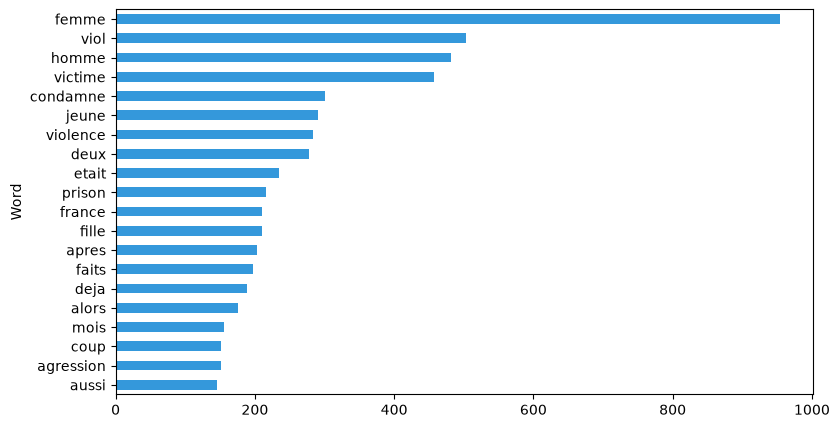

In [42]:
#get top 20 words and reverse order so highest count is at the top of the chart
top20 = df1.head(20).iloc[::-1]

#Plot a horizontal bar chart of 20 most reoccurring words
top20.plot.barh(x='Word', y='Count', legend=False, figsize=(9, 5), color='#3498db')